<a href="https://colab.research.google.com/github/geojose911/Python-Basics/blob/main/Python_Sample4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/Mall_Customers.csv')
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
data.shape

(200, 5)

In [ ]:
data.isna().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


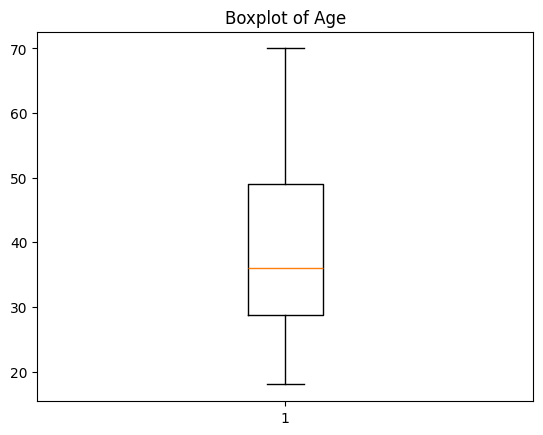

In [ ]:
# boxplot outlier

plt.boxplot(data['Age'])
plt.title('Boxplot of Age')
plt.show()

In [ ]:
data.dtypes

,0
CustomerID,int64
Genre,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


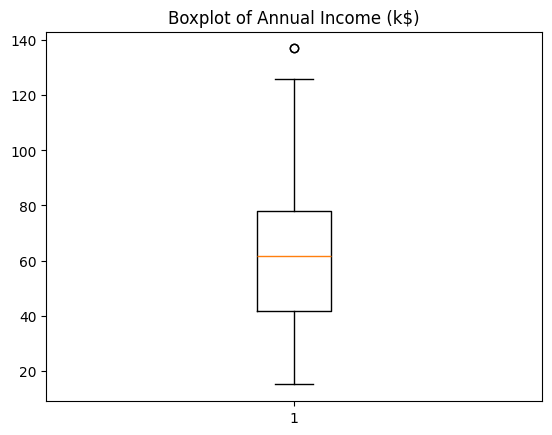

In [ ]:
plt.boxplot(data['Annual Income (k$)'])
plt.title('Boxplot of Annual Income (k$)')
plt.show()

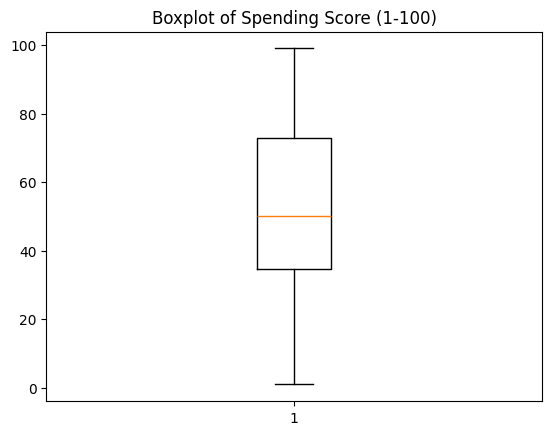

In [ ]:
plt.boxplot(data['Spending Score (1-100)'])
plt.title('Boxplot of Spending Score (1-100)')
plt.show()

In [ ]:
Q1 = np.percentile(data['Annual Income (k$)'],25)
Q2 = np.percentile(data['Annual Income (k$)'],50)
Q3 = np.percentile(data['Annual Income (k$)'],75)
print(Q1)
print(Q2)
print(Q3)

41.5
61.5
78.0


<Axes: ylabel='Annual Income (k$)'>

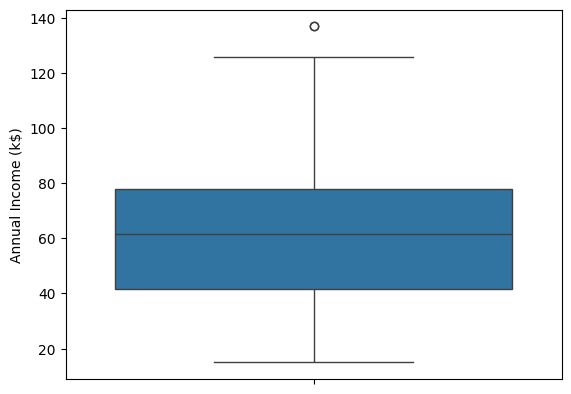

In [ ]:
sns.boxplot(data['Annual Income (k$)'])


In [ ]:
data['Annual Income (k$)'].median()

61.5

In [ ]:
IQR = Q3-Q1
print(IQR)

36.5


In [ ]:
up_lim = Q3+1.5*IQR
low_lim = Q1-1.5*IQR

In [ ]:
print(up_lim)
print(low_lim)

132.75
-13.25


In [ ]:
outlier = []
for x in data['Annual Income (k$)']:
    if x > up_lim or x < low_lim:
        outlier.append(x)

In [ ]:
outlier

[137, 137]

<Axes: ylabel='Annual Income (k$)'>

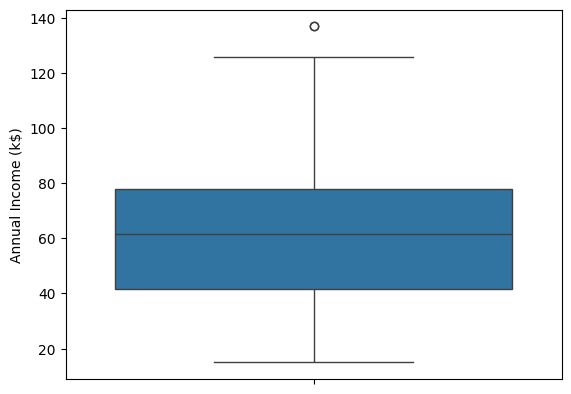

In [ ]:
sns.boxplot(data['Annual Income (k$)'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Genre'] = le.fit_transform(data['Genre'])
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [ ]:
# drop constumerID with all unique value

x=data.drop('CustomerID', axis=1)

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42,n_init=10)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)
wcss

[308862.06000000006,
 212889.44245524294,
 143391.59236035674,
 104414.67534220174,
 75399.61541401486,
 58348.64136331505,
 51130.690081263754,
 44687.23553400544,
 40857.18667502088,
 37175.97669994117]

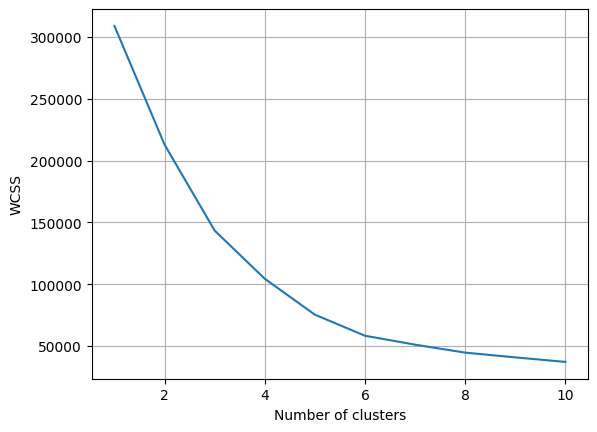

In [ ]:
plt.plot(range(1,11),wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()

In [ ]:
km = KMeans(n_clusters=5,n_init=10)
km.fit(x)
cluster_labels=km.predict(x)
cluster_labels



array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0], dtype=int32)

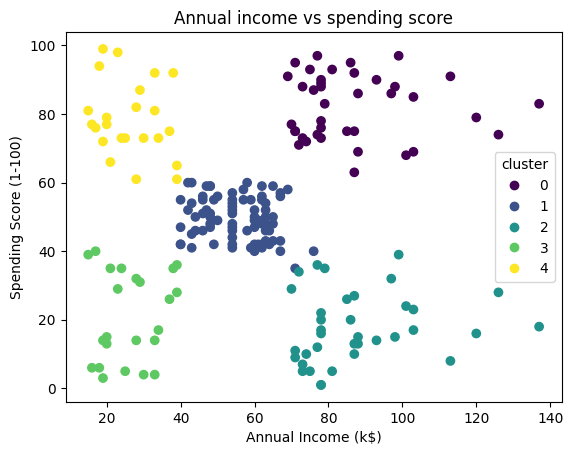

In [ ]:
scatter = plt.scatter(x['Annual Income (k$)'],x['Spending Score (1-100)'],c=cluster_labels)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Annual income vs spending score')
plt.legend(*scatter.legend_elements(),title='cluster')
plt.show()

In [ ]:
# function to predict cluster for a new customer
def predict_cluster(Genre,age, annual_income, spending_score):
   new_data = [[Genre,age, annual_income, spending_score]]
   cluster = km.predict(new_data)
   return cluster[0]

In [ ]:
# example

new_customer_income = 50
new_customer_spending_score = 100
Genre = 'Male'
Genre = 1 if Genre=='Male' else 0
age = 25

In [ ]:
predicted_cluster = predict_cluster(Genre,age, new_customer_income, new_customer_spending_score)
print(f'The customer belongs to custer:{predicted_cluster}')

The customer belongs to custer:4


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
